# BIG DATA ANALYSIS

# Import Libraries & Create SparkSession

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ratings_Beauty.csv')

In [3]:
df.head()

,UserId,ProductId,Rating,Timestamp
0,A39HTATAQ9V7YF,0205616461,5.0,1369699200
1,A3JM6GV9MNOF9X,0558925278,3.0,1355443200
2,A1Z513UWSAAO0F,0558925278,5.0,1404691200
3,A1WMRR494NWEWV,0733001998,4.0,1382572800
4,A3IAAVS479H7M7,0737104473,1.0,1274227200


In [4]:
df.tail()

,UserId,ProductId,Rating,Timestamp
2023065,A3DEHKPFANB8VA,B00LORWRJA,5.0,1405296000
2023066,A3DEHKPFANB8VA,B00LOS7MEE,5.0,1405296000
2023067,AG9TJLJUN5OM3,B00LP2YB8E,5.0,1405382400
2023068,AYBIB14QOI9PC,B00LPVG6V0,5.0,1405555200
2023069,A1PB6OT0OOPKNQ,B00LU0LTOU,5.0,1405641600


## 2. Schema & Basic Stats

In [5]:
df.describe()

,Rating,Timestamp
count,2.023070e+06,2.023070e+06
mean,4.149036e+00,1.360389e+09
std,1.311505e+00,4.611860e+07
min,1.000000e+00,9.087552e+08
25%,4.000000e+00,1.350259e+09
50%,5.000000e+00,1.372810e+09
75%,5.000000e+00,1.391472e+09
max,5.000000e+00,1.406074e+09


In [6]:
df.info

<bound method DataFrame.info of                  UserId   ProductId  Rating   Timestamp
0        A39HTATAQ9V7YF  0205616461     5.0  1369699200
1        A3JM6GV9MNOF9X  0558925278     3.0  1355443200
2        A1Z513UWSAAO0F  0558925278     5.0  1404691200
3        A1WMRR494NWEWV  0733001998     4.0  1382572800
4        A3IAAVS479H7M7  0737104473     1.0  1274227200
...                 ...         ...     ...         ...
2023065  A3DEHKPFANB8VA  B00LORWRJA     5.0  1405296000
2023066  A3DEHKPFANB8VA  B00LOS7MEE     5.0  1405296000
2023067   AG9TJLJUN5OM3  B00LP2YB8E     5.0  1405382400
2023068   AYBIB14QOI9PC  B00LPVG6V0     5.0  1405555200
2023069  A1PB6OT0OOPKNQ  B00LU0LTOU     5.0  1405641600

[2023070 rows x 4 columns]>

In [7]:
df.columns

Index(['UserId', 'ProductId', 'Rating', 'Timestamp'], dtype='object')

## Start Spark Session

In [8]:
!pip install pyspark

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Initialize Spark
spark0 = SparkSession.builder.appName("AmazonBeautyAnalysis").getOrCreate()


In [10]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("AmazonBeautyAnalysis").getOrCreate()
from pyspark.sql.functions import col, avg, count, desc

In [11]:
file_path = r"C:\Users\gokak\Documents\CODT\ratings_Beauty.csv"  # Update if needed
df = spark.read.csv(file_path, header=True, inferSchema=True)
df.show(5)

+--------------+----------+------+----------+
|        UserId| ProductId|Rating| Timestamp|
+--------------+----------+------+----------+
|A39HTATAQ9V7YF|0205616461|   5.0|1369699200|
|A3JM6GV9MNOF9X|0558925278|   3.0|1355443200|
|A1Z513UWSAAO0F|0558925278|   5.0|1404691200|
|A1WMRR494NWEWV|0733001998|   4.0|1382572800|
|A3IAAVS479H7M7|0737104473|   1.0|1274227200|
+--------------+----------+------+----------+
only showing top 5 rows



In [12]:
print(f"Total records: {df.count()}")
df.printSchema()


Total records: 2023070
root
 |-- UserId: string (nullable = true)
 |-- ProductId: string (nullable = true)
 |-- Rating: double (nullable = true)
 |-- Timestamp: integer (nullable = true)



## 3. Check for Missing Values

In [13]:
df.select([col(c).isNull().cast("int").alias(c) for c in df.columns]).groupBy().sum().show()

+-----------+--------------+-----------+--------------+
|sum(UserId)|sum(ProductId)|sum(Rating)|sum(Timestamp)|
+-----------+--------------+-----------+--------------+
|          0|             0|          0|             0|
+-----------+--------------+-----------+--------------+



In [14]:
df_clean = df.dropna()
print(f"Cleaned record count: {df_clean.count()}")

Cleaned record count: 2023070


In [15]:
df.select([col(c).isNull().cast("int").alias(c) for c in df.columns]).groupBy().sum().show()

+-----------+--------------+-----------+--------------+
|sum(UserId)|sum(ProductId)|sum(Rating)|sum(Timestamp)|
+-----------+--------------+-----------+--------------+
|          0|             0|          0|             0|
+-----------+--------------+-----------+--------------+



## 4. Average Rating Per Product

In [16]:
avg_rating_df = df_clean.groupBy("ProductId").agg(avg("Rating").alias("average_rating"))
avg_rating_df.orderBy(desc("average_rating")).show(5)

+----------+--------------+
| ProductId|average_rating|
+----------+--------------+
|B000052YQV|           5.0|
|B0002269UQ|           5.0|
|B0006LP986|           5.0|
|B00021PAS4|           5.0|
|B00005NAPK|           5.0|
+----------+--------------+
only showing top 5 rows



## 5. Top 10 Most Reviewed Products

In [17]:
top_reviewed = df_clean.groupBy("ProductId").agg(count("*").alias("review_count"))
top_reviewed.orderBy(desc("review_count")).show(10)

+----------+------------+
| ProductId|review_count|
+----------+------------+
|B001MA0QY2|        7533|
|B0009V1YR8|        2869|
|B0043OYFKU|        2477|
|B0000YUXI0|        2143|
|B003V265QW|        2088|
|B000ZMBSPE|        2041|
|B003BQ6QXK|        1918|
|B004OHQR1Q|        1885|
|B00121UVU0|        1838|
|B000FS05VG|        1589|
+----------+------------+
only showing top 10 rows



## 6. Best Rated Products (with at least 100 reviews)

In [18]:
best_rated = df_clean.groupBy("ProductId") \
    .agg(avg("Rating").alias("avg_rating"), count("*").alias("num_reviews")) \
    .filter(col("num_reviews") >= 100) \
    .orderBy(desc("avg_rating"))
best_rated.show(5)


+----------+-----------------+-----------+
| ProductId|       avg_rating|num_reviews|
+----------+-----------------+-----------+
|B00I46E8DC|4.912790697674419|        172|
|B008DWSJ1O|4.894308943089431|        123|
|B00GJX58PE|4.889447236180905|        398|
|B00JX979CQ|4.883495145631068|        103|
|B00IBS9QC6|4.874476987447698|        239|
+----------+-----------------+-----------+
only showing top 5 rows



##  7. Worst Rated Products (with at least 100 reviews)

In [19]:
worst_rated = df_clean.groupBy("ProductId") \
    .agg(avg("Rating").alias("avg_rating"), count("*").alias("num_reviews")) \
    .filter(col("num_reviews") >= 100) \
    .orderBy("avg_rating")
worst_rated.show(5)

+----------+------------------+-----------+
| ProductId|        avg_rating|num_reviews|
+----------+------------------+-----------+
|B001A4826E|  1.62015503875969|        129|
|B0037LKIAG|1.9655172413793103|        145|
|B003QUHWT8|2.0901960784313727|        255|
|B000NSQMLK| 2.109090909090909|        110|
|B000TVNIY0|2.1132075471698113|        106|
+----------+------------------+-----------+
only showing top 5 rows



## ## 8. Most Active Users

In [20]:
most_active_users = df_clean.groupBy("UserID").count().orderBy(desc("count"))
most_active_users.show(5)

+--------------+-----+
|        UserID|count|
+--------------+-----+
|A3KEZLJ59C1JVH|  389|
|A281NPSIMI1C2R|  336|
|A3M174IC0VXOS2|  326|
|A2V5R832QCSOMX|  278|
|A3LJLRIZL38GG3|  276|
+--------------+-----+
only showing top 5 rows



## 9. Average Rating Given by Users

In [21]:
user_avg = df_clean.groupBy("UserID").agg(avg("Rating").alias("user_avg_rating"))
user_avg.orderBy(desc("user_avg_rating")).show(5)

+--------------+---------------+
|        UserID|user_avg_rating|
+--------------+---------------+
|A3SEDTPDP0G66D|            5.0|
|A3HH9WA1LOMK9P|            5.0|
|A35X82IY1F5CHZ|            5.0|
|A1IRID4AA6MTIV|            5.0|
|A3O2ZE5VF507AP|            5.0|
+--------------+---------------+
only showing top 5 rows



## 10.Visualizations 

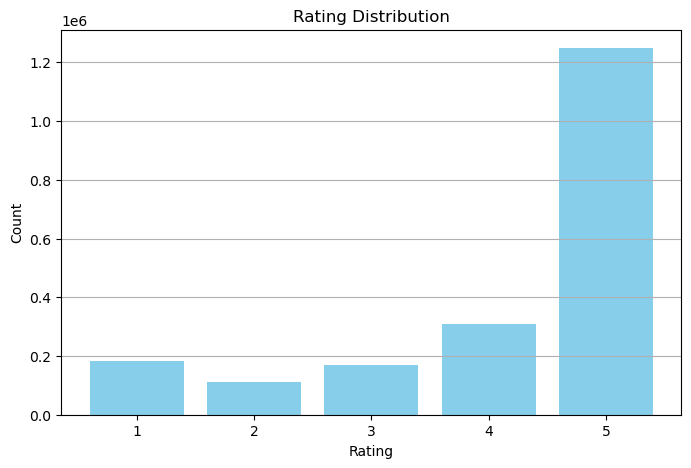

In [22]:
ratings_dist = df_clean.groupBy("Rating").count().orderBy("Rating").toPandas() #asin ➝ ProductId  ||| overall ➝ Rating  ||| reviewerID ➝ UserId

# Bar Chart
plt.figure(figsize=(8,5))
plt.bar(ratings_dist["Rating"], ratings_dist["count"], color="skyblue")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis="y")
plt.show()


## 11: Visualization – Worst Rated Products

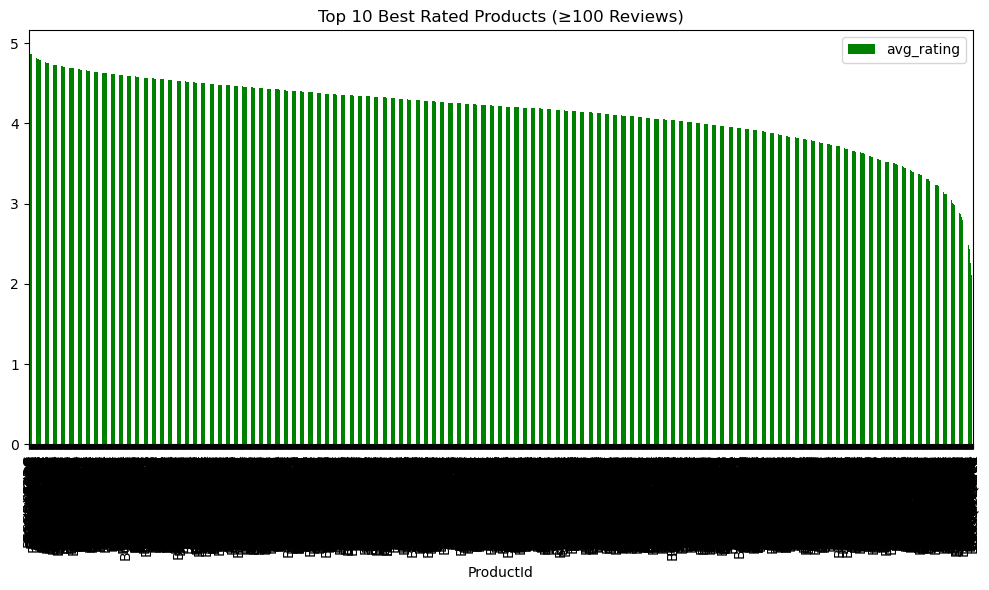

In [23]:
pandas_best_rated = best_rated.toPandas()
pandas_best_rated.plot(kind='bar', x='ProductId', y='avg_rating',
                       title='Top 10 Best Rated Products (≥100 Reviews)',
                       figsize=(10,6), color='green')
plt.tight_layout()
plt.show()

## 12: Visualization – Worst Rated Products

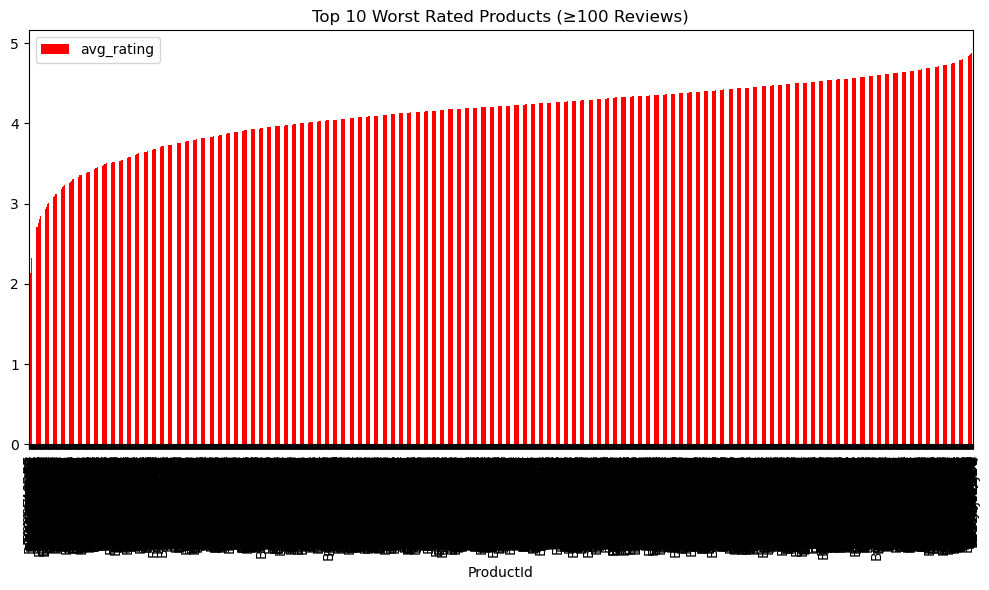

In [24]:
pandas_worst_rated = worst_rated.toPandas()
pandas_worst_rated.plot(kind='bar', x='ProductId', y='avg_rating',
                        title='Top 10 Worst Rated Products (≥100 Reviews)',
                        figsize=(10,6), color='red')
plt.tight_layout()
plt.show()


In [25]:
spark.stop()